In [3]:
import os
os.chdir('/home/datahouse1/zengchuanlong/workplace/GeoBFN')
os.getcwd()

'/home/datahouse1/zengchuanlong/workplace/GeoBFN'

In [4]:
import pickle

with open('dataset/competition_round2/competition_round2.pkl', 'rb') as f:
    competition_data = pickle.load(f)

In [5]:
competition_data[0]

{'natoms': 16,
 'coordinates': array([[ 2.90944648e+00, -7.53407887e+00,  3.45550898e+00],
        [ 1.96424648e+00, -8.27297887e+00,  3.45430898e+00],
        [ 6.07846478e-01, -7.96247887e+00,  3.45390898e+00],
        [-1.77353522e-01, -6.82077887e+00,  3.45390898e+00],
        [ 1.37046478e-01, -5.48917887e+00,  3.45400898e+00],
        [ 1.72514648e+00, -4.83187887e+00,  3.45350898e+00],
        [-9.36053522e-01, -4.44177887e+00,  3.45430898e+00],
        [-6.75353522e-01, -3.25537887e+00,  3.45440898e+00],
        [-2.35435352e+00, -4.88027887e+00,  3.45450898e+00],
        [-2.68705352e+00, -6.18057887e+00,  3.45420898e+00],
        [-4.32055352e+00, -6.73457887e+00,  3.45430898e+00],
        [-1.63685352e+00, -7.24007887e+00,  3.45380898e+00],
        [-1.92175352e+00, -8.42187887e+00,  3.45340898e+00],
        [ 2.06844648e+00, -9.38577887e+00,  3.45330898e+00],
        [ 1.84647837e-03, -8.78687887e+00,  3.45330898e+00],
        [-3.09945352e+00, -4.08327887e+00,  3.45480898e

In [6]:
import pandas as pd

# Extract natoms values from competition_data
natoms_data = [mol['natoms'] for mol in competition_data]

# Create a DataFrame
df = pd.DataFrame({'natoms': natoms_data})

# Save to CSV
df.to_csv('natoms_data.csv', index=False)

print(f"Saved {len(natoms_data)} natoms values to natoms_data.csv")
print(f"First few values: {natoms_data[:10]}")

Saved 57252 natoms values to natoms_data.csv
First few values: [16, 15, 27, 27, 17, 14, 14, 14, 27, 27]


In [7]:
len(competition_data)

57252

In [8]:
from collections import Counter

# Analyze the competition_data structure and content
print(f"Total number of molecules in competition_data: {len(competition_data)}")
print("\nFirst molecule structure:")
first_mol = competition_data[0]
print(f"Keys: {first_mol.keys()}")
print(f"Number of atoms: {first_mol['natoms']}")
print(f"Elements: {first_mol['elements']}")
print(f"Coordinates shape: {first_mol['coordinates'].shape}")
print(f"Properties value: {first_mol['properties']}")

print("\nSample of molecule sizes:")
sizes = [mol['natoms'] for mol in competition_data[:10]]
print(f"First 10 molecule sizes: {sizes}")

print("\nStatistics of molecule sizes:")
all_sizes = [mol['natoms'] for mol in competition_data]
print(f"Min atoms: {min(all_sizes)}")
print(f"Max atoms: {max(all_sizes)}")
print(f"Average atoms: {sum(all_sizes)/len(all_sizes):.2f}")

print("\nStatistics of properties values:")
all_properties = [mol['properties'] for mol in competition_data]
print(f"Min property: {min(all_properties):.4f}")
print(f"Max property: {max(all_properties):.4f}")
print(f"Average property: {sum(all_properties)/len(all_properties):.4f}")

# Count unique elements across all molecules
all_elements = []
for mol in competition_data:
    all_elements.extend(mol['elements'])
element_counts = Counter(all_elements)
print(f"\nElement distribution (top 10):")
for element, count in element_counts.most_common(10):
    print(f"{element}: {count}")

Total number of molecules in competition_data: 57252

First molecule structure:
Keys: dict_keys(['natoms', 'coordinates', 'elements', 'properties'])
Number of atoms: 16
Elements: [8, 6, 7, 6, 6, 17, 6, 8, 6, 6, 17, 6, 8, 1, 1, 1]
Coordinates shape: (16, 3)
Properties value: 35.551597595214844

Sample of molecule sizes:
First 10 molecule sizes: [16, 15, 27, 27, 17, 14, 14, 14, 27, 27]

Statistics of molecule sizes:
Min atoms: 6
Max atoms: 29
Average atoms: 22.61

Statistics of properties values:
Min property: -4.8820
Max property: 124.0469
Average property: 21.5179

Element distribution (top 10):
1: 598781
6: 456748
7: 116297
8: 90468
16: 15146
9: 9180
17: 6405
15: 810
35: 795


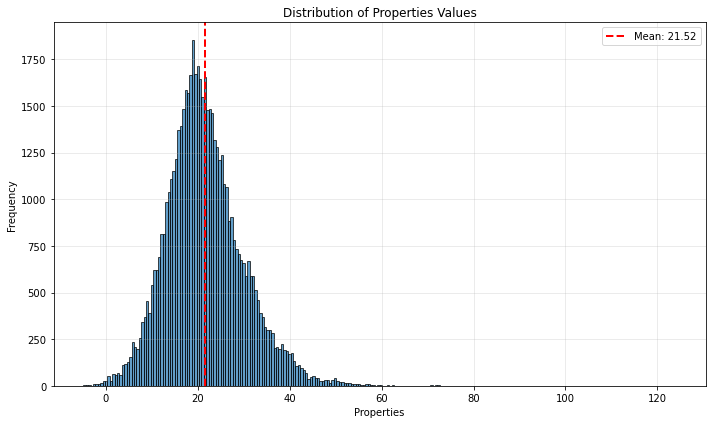

Statistics for properties:
Mean: 21.5179
Standard deviation: 8.3307
Min: -4.8820
Max: 124.0469


In [9]:
import numpy as np

import matplotlib.pyplot as plt

# Extract properties values from competition_data
properties_values = [mol['properties'] for mol in competition_data]

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(properties_values, bins='auto', alpha=0.7, edgecolor='black')
plt.title('Distribution of Properties Values')
plt.xlabel('Properties')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Add statistics text
mean_val = np.mean(properties_values)
std_val = np.std(properties_values)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Statistics for properties:")
print(f"Mean: {mean_val:.4f}")
print(f"Standard deviation: {std_val:.4f}")
print(f"Min: {min(properties_values):.4f}")
print(f"Max: {max(properties_values):.4f}")

In [10]:
import collections
import pprint # For potentially larger lists

# Assuming _data_list is already defined from your previous inputs

def calculate_natom_histogram(data_list):
    """
    Calculates the distribution (histogram) of the number of atoms per molecule.

    Args:
        data_list: A list of dictionaries, where each dictionary is expected
                   to have an integer key 'natoms'.

    Returns:
        A list where the index represents the number of atoms (starting from 0)
        and the value at that index is the count of molecules with that many
        atoms. Returns an empty list if the input data_list is empty or contains
        no valid 'natoms' entries.
    """
    if not data_list:
        print("Input data_list is empty.")
        return []

    # --- Extract 'natoms' values with basic validation ---
    all_natoms = []
    for i, item in enumerate(data_list):
        num_atoms = item.get('natoms') # Use .get() for safety
        if num_atoms is None:
            print(f"Warning: Molecule at index {i} missing 'natoms' key. Skipping.")
            continue
        # Check if it's a non-negative integer
        if isinstance(num_atoms, int) and num_atoms >= 0:
            all_natoms.append(num_atoms)
        else:
            print(f"Warning: Molecule at index {i} has invalid 'natoms' value ({num_atoms}). Skipping.")
            continue

    if not all_natoms:
        print("No valid 'natoms' values found in the data_list.")
        return []

    # --- Method 1: Using basic list manipulation (closer to example output structure) ---

    # Find the maximum number of atoms to determine histogram size
    max_natoms = max(all_natoms)

    # Initialize histogram with zeros. Length is max_natoms + 1 to cover index 0 to max_natoms.
    histogram = [0] * (max_natoms + 1)

    # Populate the histogram
    for num_atoms in all_natoms:
        histogram[num_atoms] += 1

    return histogram

    # --- Method 2: Using collections.Counter (More Pythonic for counting) ---
    # counts = collections.Counter(all_natoms)
    # max_natoms = max(counts.keys()) if counts else -1
    # # Create the list representation, filling in zeros for missing counts
    # histogram = [counts.get(i, 0) for i in range(max_natoms + 1)]
    # return histogram


# --- Example Usage ---

# Calculate the histogram
n_atom_histogram = calculate_natom_histogram(competition_data)

# Print the result
print(f"n_atom_histogram: {n_atom_histogram}")

# If you have a much larger dataset and the output list is very long,
# you might want to print it differently, e.g., showing non-zero counts:
# print("\nAtom Count Distribution (Non-zero counts):")
# for num_atoms, count in enumerate(n_atom_histogram):
#     if count > 0:
#         print(f"  Atoms: {num_atoms}, Count: {count}")

n_atom_histogram: [0, 0, 0, 0, 0, 0, 3, 13, 37, 79, 153, 297, 497, 908, 1098, 1485, 2078, 2532, 2691, 3140, 3301, 3731, 3476, 3914, 4428, 4530, 4469, 5054, 4929, 4409]


In [12]:
_data_list = competition_data

Example molecule data structure:
Keys: ['natoms', 'coordinates', 'elements', 'properties']
Example natoms: 16
Example elements (first 5): [8, 6, 7, 6, 6]
Example coordinates (first 2): [[ 2.90944648 -7.53407887  3.45550898]
 [ 1.96424648 -8.27297887  3.45430898]]

Total number of molecules: 57252
Molecule size statistics:
  Min atoms: 6
  Max atoms: 29
  Average atoms: 22.61
  Median atoms: 23.0

Element frequency distribution:
  1: 598781 (46.25%)
  6: 456748 (35.28%)
  7: 116297 (8.98%)
  8: 90468 (6.99%)
  16: 15146 (1.17%)
  9: 9180 (0.71%)
  17: 6405 (0.49%)
  15: 810 (0.06%)
  35: 795 (0.06%)


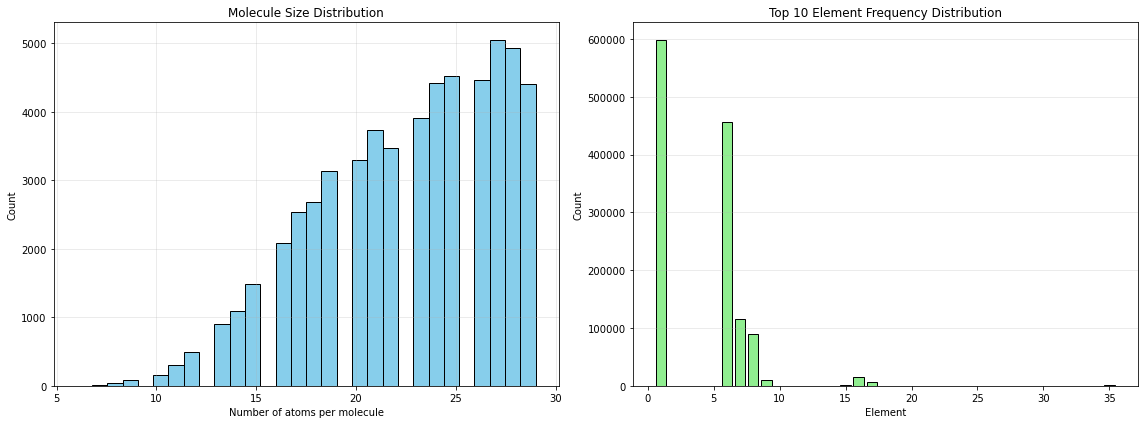

In [13]:
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt

# Check data structure for one example
print(f"Example molecule data structure:")
print(f"Keys: {list(_data_list[0].keys())}")
print(f"Example natoms: {_data_list[0]['natoms']}")
print(f"Example elements (first 5): {_data_list[0]['elements'][:5]}")
print(f"Example coordinates (first 2): {_data_list[0]['coordinates'][:2]}")

# 1. Molecule size distribution
molecule_sizes = [molecule['natoms'] for molecule in _data_list]
print(f"\nTotal number of molecules: {len(_data_list)}")
print(f"Molecule size statistics:")
print(f"  Min atoms: {min(molecule_sizes)}")
print(f"  Max atoms: {max(molecule_sizes)}")
print(f"  Average atoms: {np.mean(molecule_sizes):.2f}")
print(f"  Median atoms: {np.median(molecule_sizes)}")

# 2. Element frequency distribution
all_elements = []
for molecule in _data_list:
    all_elements.extend(molecule['elements'])

element_counts = Counter(all_elements)
print(f"\nElement frequency distribution:")
for element, count in sorted(element_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {element}: {count} ({count/len(all_elements)*100:.2f}%)")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot molecule size histogram
ax1.hist(molecule_sizes, bins=30, color='skyblue', edgecolor='black', density=False)
ax1.set_xlabel('Number of atoms per molecule')
ax1.set_ylabel('Count')
ax1.set_title('Molecule Size Distribution')
ax1.grid(alpha=0.3)

# Plot element frequency
elements = [e for e, c in element_counts.most_common(10)]
counts = [c for e, c in element_counts.most_common(10)]
ax2.bar(elements, counts, color='lightgreen', edgecolor='black')
ax2.set_xlabel('Element')
ax2.set_ylabel('Count')
ax2.set_title('Top 10 Element Frequency Distribution')
ax2.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()